# #30DayMapChallenge
## Day 25: Hexagons

### Data Source
1. WorldClim version 2.1 climate data for 1970-2000: https://www.worldclim.org/data/worldclim21.html

### 1. Setup

In [27]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import glob
import os

In [33]:
# Load Iceland polygon
folder = r"D:\Dropbox\Protocol Creative\Protocol30DayMapChallenge2025\Day 25"
iceland_file = "D:\Dropbox\Protocol Creative\Protocol30DayMapChallenge2025\Day 25\is.json"
iceland = gpd.read_file(iceland_file)
iceland = iceland.to_crs("EPSG:4326")  # WC2.1 rasters are in WGS84

### 2a. Clip and Calculate Annual Mean Temperature

In [ ]:
tif_files = sorted(glob.glob("wc2.1_30s_tavg/*.tif"))

if len(tif_files) != 12:
    print(f"Warning: Expected 12 monthly rasters, found {len(tif_files)}")

In [ ]:
monthly_means = []

for tif in tif_files:
    with rasterio.open(tif) as src:
        out_img, out_transform = mask(src, iceland.geometry, crop=True)
        data = out_img[0]  # take band 1
        
        # Remove no-data values
        data = data[data != src.nodata]
        
        monthly_means.append(data.mean())

# Convert to numpy array
monthly_means = np.array(monthly_means)

print("Monthly mean temperatures over Iceland:")
print(monthly_means)
print("Annual mean temp:", monthly_means.mean())

In [ ]:
# Clip and accumulate rasters
sum_arr = None  # accumulator

for i, tif in enumerate(tif_files):
    print(f"Processing month {i+1}: {os.path.basename(tif)}")
    
    with rasterio.open(tif) as src:
        # Mask to Iceland and crop
        out_img, out_transform = mask(src, iceland.geometry, crop=True)
        data = out_img[0].astype('float32')  # single band
        data[data == src.nodata] = np.nan     # handle nodata values
        
        if sum_arr is None:
            sum_arr = data
            # Copy metadata and update for clipped raster
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": data.shape[0],
                "width": data.shape[1],
                "transform": out_transform,
                "dtype": "float32",
                "count": 1
            })
        else:
            sum_arr += data

# Compute annual mean
annual_mean = sum_arr / len(tif_files)

# Save annual mean raster
out_raster = os.path.join(folder, "annual_tavg_iceland.tif")
with rasterio.open(out_raster, 'w', **out_meta) as dst:
    dst.write(annual_mean, 1)

print("Saved annual mean temperature raster:", out_raster)

### 2b. Clip and Calculate Annual Mean Precipitation

In [ ]:
tif_files = sorted(glob.glob("wc2.1_30s_prec/*.tif"))

if len(tif_files) != 12:
    print(f"Warning: Expected 12 monthly rasters, found {len(tif_files)}")

In [ ]:
monthly_means = []

for tif in tif_files:
    with rasterio.open(tif) as src:
        out_img, out_transform = mask(src, iceland.geometry, crop=True)
        data = out_img[0]  # take band 1
        
        # Remove no-data values
        data = data[data != src.nodata]
        
        monthly_means.append(data.mean())

# Convert to numpy array
monthly_means = np.array(monthly_means)

print("Monthly mean precipitation over Iceland:")
print(monthly_means)
print("Annual mean precipitation:", monthly_means.mean())

In [ ]:
# Clip and accumulate rasters
sum_arr = None  # accumulator

for i, tif in enumerate(tif_files):
    print(f"Processing month {i+1}: {os.path.basename(tif)}")
    
    with rasterio.open(tif) as src:
        # Mask to Iceland and crop
        out_img, out_transform = mask(src, iceland.geometry, crop=True)
        data = out_img[0].astype('float32')  # single band
        data[data == src.nodata] = np.nan     # handle nodata values
        
        if sum_arr is None:
            sum_arr = data
            # Copy metadata and update for clipped raster
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": data.shape[0],
                "width": data.shape[1],
                "transform": out_transform,
                "dtype": "float32",
                "count": 1
            })
        else:
            sum_arr += data

# Compute annual mean
annual_mean = sum_arr / len(tif_files)

# Save annual mean raster
out_raster = os.path.join(folder, "annual_prec_iceland.tif")
with rasterio.open(out_raster, 'w', **out_meta) as dst:
    dst.write(annual_mean, 1)

print("Saved annual mean precipitation raster:", out_raster)

### 2c. Clip Elevation

In [ ]:
elev_file = "wc2.1_30s_elev.tif"

In [ ]:
# Output path
out_raster = os.path.join(folder, "elev_iceland.tif")

# Mask elevation raster
with rasterio.open(elev_file) as src:
    # Mask and crop
    out_img, out_transform = mask(src, iceland.geometry, crop=True)
    data = out_img[0].astype('float32')
    
    # Handle nodata
    data[data == src.nodata] = np.nan
    
    # Update metadata
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": data.shape[0],
        "width": data.shape[1],
        "transform": out_transform,
        "dtype": "float32",
        "count": 1
    })
    
    # Write clipped raster
    with rasterio.open(out_raster, 'w', **out_meta) as dst:
        dst.write(data, 1)

print("Saved clipped elevation raster:", out_raster)

### 3. Generate hexagons

In [35]:
import geopandas as gpd
import h3
from shapely.geometry import Polygon
import pandas as pd

In [41]:
# Generate H3 hexagons at resolution 6
hexagons = set()

# Polyfill the Iceland geometry with H3 hexagons
for geom in iceland.geometry:
    if geom.geom_type == 'Polygon':
        # Get exterior coordinates as list of (lat, lon) tuples
        exterior_coords = [(lat, lon) for lon, lat in geom.exterior.coords[:-1]]
        
        # Create LatLngPoly object (H3 v4 format)
        h3poly = h3.LatLngPoly(exterior_coords)
        
        # Generate hexagons
        hex_ids = h3.polygon_to_cells(h3poly, 6)
        hexagons.update(hex_ids)
        
    elif geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            exterior_coords = [(lat, lon) for lon, lat in poly.exterior.coords[:-1]]
            h3poly = h3.LatLngPoly(exterior_coords)
            hex_ids = h3.polygon_to_cells(h3poly, 6)
            hexagons.update(hex_ids)

# Convert H3 hexagons to GeoDataFrame
def h3_to_polygon(hex_id):
    """Convert H3 hexagon to Shapely Polygon"""
    boundary = h3.cell_to_boundary(hex_id)
    # H3 returns coordinates as (lat, lon), convert to (lon, lat) for Shapely
    coords = [(lon, lat) for lat, lon in boundary]
    return Polygon(coords)

# Create GeoDataFrame
hex_polygons = [h3_to_polygon(hex_id) for hex_id in hexagons]
hex_gdf = gpd.GeoDataFrame(
    {'hex_id': list(hexagons)},
    geometry=hex_polygons,
    crs="EPSG:4326"
)

print(f"Generated {len(hex_gdf)} H3 hexagons at resolution 6")
print(hex_gdf.head())

# Save to file
hex_gdf.to_file("iceland_h3_res6.gpkg", layer="h3_hexagons", driver="GPKG")

Generated 3220 H3 hexagons at resolution 6
            hex_id                                           geometry
0  86074069fffffff  POLYGON ((-19.27254 64.67317, -19.32724 64.692...
1  8607418f7ffffff  POLYGON ((-18.31502 63.49104, -18.36623 63.509...
2  8607410a7ffffff  POLYGON ((-18.96830 63.61977, -19.02048 63.638...
3  86074079fffffff  POLYGON ((-18.95552 64.70856, -19.00994 64.727...
4  86074386fffffff  POLYGON ((-19.53913 64.03951, -19.59279 64.058...


### 4. Write values into hexagons

In [43]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
from shapely.geometry import mapping

In [45]:
elevation = "elev_iceland.tif"
temperature = "annual_tavg_iceland.tif"
precipitation = "annual_prec_iceland.tif"
h3_r6 = "iceland_h3_res6.gpkg"

In [ ]:
# Read the H3 hexagons
hex_gdf = gpd.read_file(h3_r6)

# Ensure it's in the right CRS
if hex_gdf.crs != "EPSG:4326":
    hex_gdf = hex_gdf.to_crs("EPSG:4326")

In [13]:
def extract_raster_stats(hexagon_geom, raster_path):
    """
    Extract statistics from a raster for a given hexagon geometry.
    Returns mean, min, max, and median values.
    """
    try:
        with rasterio.open(raster_path) as src:
            # Mask the raster with the hexagon geometry
            out_image, out_transform = mask(src, [mapping(hexagon_geom)], crop=True, nodata=src.nodata)
            
            # Get the data from the first band
            data = out_image[0]
            
            # Filter out nodata values
            if src.nodata is not None:
                valid_data = data[data != src.nodata]
            else:
                valid_data = data[~np.isnan(data)]
            
            # Calculate statistics
            if len(valid_data) > 0:
                return {
                    'mean': float(np.mean(valid_data)),
                    'min': float(np.min(valid_data)),
                    'max': float(np.max(valid_data)),
                    'median': float(np.median(valid_data))
                }
            else:
                return {
                    'mean': np.nan,
                    'min': np.nan,
                    'max': np.nan,
                    'median': np.nan
                }
    except Exception as e:
        print(f"Error processing hexagon: {e}")
        return {
            'mean': np.nan,
            'min': np.nan,
            'max': np.nan,
            'median': np.nan
        }

In [80]:
# Extract values for each raster
print("Extracting elevation values...")
hex_gdf['elev_mean'] = hex_gdf.geometry.apply(lambda geom: extract_raster_stats(geom, elevation)['mean'])

print("Extracting temperature values...")
hex_gdf['temp_mean'] = hex_gdf.geometry.apply(lambda geom: extract_raster_stats(geom, temperature)['mean'])

print("Extracting precipitation values...")
hex_gdf['prec_mean'] = hex_gdf.geometry.apply(lambda geom: extract_raster_stats(geom, precipitation)['mean'])

print("\nDataFrame summary:")
print(hex_gdf.head())
print(f"\nTotal hexagons: {len(hex_gdf)}")
print("\nColumn statistics:")
print(hex_gdf[['elev_mean', 'temp_mean', 'prec_mean']].describe())

# Save the enriched hexagons
hex_gdf.to_file("iceland_h3_res6_with_data.gpkg", layer="h3_hexagons", driver="GPKG")

Extracting elevation values...
Extracting temperature values...
Extracting precipitation values...

DataFrame summary:
            hex_id   elev_mean  temp_mean   prec_mean  \
0  8607402e7ffffff  602.925903   1.082304  113.650208   
1  860771aafffffff  586.595215   1.194742   81.014877   
3  86074400fffffff  958.259277  -1.284979  108.023666   
4  860741c77ffffff  140.268295   4.147053  134.794724   
5  860762447ffffff  726.512207   0.462195  118.909561   

                                            geometry  temp_class  prec_class  \
0  POLYGON ((-18.84460 64.15799, -18.89773 64.176...           1           2   
1  POLYGON ((-14.91242 65.40518, -14.96359 65.425...           1           1   
3  POLYGON ((-15.99550 64.68964, -16.04648 64.709...           0           2   
4  POLYGON ((-18.40015 63.74167, -18.45194 63.760...           2           2   
5  POLYGON ((-14.07307 65.14086, -14.12268 65.161...           1           2   

     color    height  
0  #8c62aa  0.602926  
1  #a5add3 

### 5. Plot H3

In [53]:
import plotly.graph_objects as go
import geopandas as gpd
import numpy as np
import pandas as pd

In [57]:
# Read the data
hex_gdf = gpd.read_file("iceland_h3_res6_with_data.gpkg", layer="h3_hexagons")

# Remove any hexagons with NaN values
hex_gdf = hex_gdf.dropna(subset=['elev_mean', 'temp_mean', 'prec_mean'])

Interactive plot saved to 'iceland_3d_bivariate_interactive_h6.html'


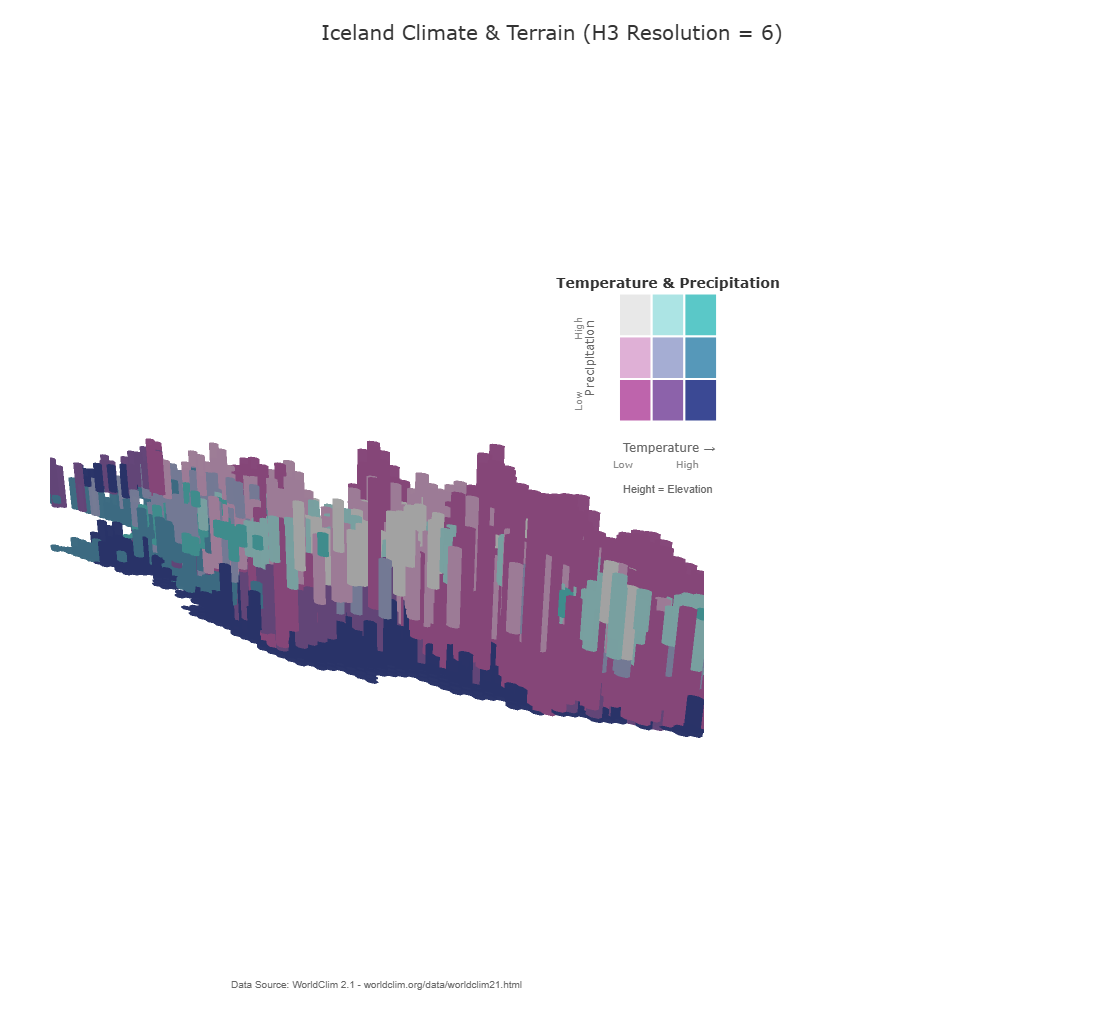

Plotted 2792 hexagons
Elevation range: 5.3m to 1915.1m
Temperature range: -6.2°C to 5.1°C
Precipitation range: 37.5mm to 174.2mm


In [82]:
# Create bivariate color classification (3x3)
def classify_bivariate(temp, prec, n_classes=3):
    """
    Classify temperature and precipitation into n_classes categories each
    Returns class indices for temp and prec (0 to n_classes-1)
    """
    temp_classes = pd.qcut(temp, q=n_classes, labels=False, duplicates='drop')
    prec_classes = pd.qcut(prec, q=n_classes, labels=False, duplicates='drop')
    return temp_classes, prec_classes

# Classify the data
hex_gdf['temp_class'], hex_gdf['prec_class'] = classify_bivariate(
    hex_gdf['temp_mean'], 
    hex_gdf['prec_mean'], 
    n_classes=3
)

# Create a 3x3 bivariate color palette
# Rows = precipitation (low to high), Columns = temperature (low to high)
bivariate_colors = np.array([
    ['#e8e8e8', '#ace4e4', '#5ac8c8'],  # Low precip
    ['#dfb0d6', '#a5add3', '#5698b9'],  # Medium precip
    ['#be64ac', '#8c62aa', '#3b4994']   # High precip
])

def get_bivariate_color(temp_class, prec_class):
    """Get color from bivariate palette"""
    return bivariate_colors[int(prec_class), int(temp_class)]

# Assign colors
hex_gdf['color'] = hex_gdf.apply(
    lambda row: get_bivariate_color(row['temp_class'], row['prec_class']), 
    axis=1
)

# Normalize elevation for extrusion (scale it appropriately)
elev_scale = 0.001  # Adjust this to control height exaggeration
hex_gdf['height'] = hex_gdf['elev_mean'] * elev_scale

# Create Plotly figure
fig = go.Figure()

# Plot each hexagon as an extruded 3D mesh
for idx, row in hex_gdf.iterrows():
    # Get hexagon coordinates
    coords = list(row.geometry.exterior.coords[:-1])
    n_vertices = len(coords)
    
    # Create vertices for base and top
    x_coords = [c[0] for c in coords]
    y_coords = [c[1] for c in coords]
    
    # Vertices: base (z=0) + top (z=height)
    x = x_coords + x_coords
    y = y_coords + y_coords
    z = [0] * n_vertices + [row['height']] * n_vertices
    
    # Create faces (triangles) for the hexagon
    i, j, k = [], [], []
    
    # Bottom face (triangulate the hexagon)
    for v in range(1, n_vertices - 1):
        i.append(0)
        j.append(v)
        k.append(v + 1)
    
    # Top face (triangulate the hexagon)
    offset = n_vertices
    for v in range(1, n_vertices - 1):
        i.append(offset)
        j.append(offset + v)
        k.append(offset + v + 1)
    
    # Side faces (two triangles per side)
    for v in range(n_vertices):
        next_v = (v + 1) % n_vertices
        
        # Triangle 1
        i.append(v)
        j.append(next_v)
        k.append(offset + v)
        
        # Triangle 2
        i.append(next_v)
        j.append(offset + next_v)
        k.append(offset + v)
    
    # Add mesh
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z,
        i=i, j=j, k=k,
        color=row['color'],
        opacity=0.95,
        flatshading=True,
        lighting=dict(ambient=0.7, diffuse=0.8, specular=0.2, roughness=0.5),
        lightposition=dict(x=100, y=200, z=300),
        hovertemplate=f'<b>Elevation:</b> {row["elev_mean"]:.1f}m<br>' +
                      f'<b>Temperature:</b> {row["temp_mean"]:.1f}°C<br>' +
                      f'<b>Precipitation:</b> {row["prec_mean"]:.1f}mm<br>' +
                      '<extra></extra>',
        showlegend=False
    ))

# Update layout
fig.update_layout(
    title=dict(
        text='Iceland Climate & Terrain (H3 Resolution = 6)',
        x=0.5,
        xanchor='center',
        font=dict(size=20, color='#333333')
    ),
    scene=dict(
        xaxis=dict(
            title='',
            showgrid=False,
            showbackground=False,
            showline=False,
            zeroline=False,
            showticklabels=False,
            showspikes=False
        ),
        yaxis=dict(
            title='',
            showgrid=False,
            showbackground=False,
            showline=False,
            zeroline=False,
            showticklabels=False,
            showspikes=False
        ),
        zaxis=dict(
            title='',
            showgrid=False,
            showbackground=False,
            showline=False,
            zeroline=False,
            showticklabels=False,
            showspikes=False
        ),
        bgcolor='rgba(240,240,240,0.3)',
        camera=dict(
            eye=dict(x=1.3, y=-1.8, z=0.8)
        ),
        aspectmode='data'
    ),
    width=1800,
    height=1000,
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=50, r=400, t=80, b=80) 
)

# Create bivariate legend annotations
legend_x_start = 0.87  # Adjusted for larger legend
legend_y_start = 0.60  # Adjusted for larger legend
legend_size = 0.05  # Size of squares

# Add colored squares for the legend
for i in range(3):
    for j in range(3):
        fig.add_shape(
            type="rect",
            xref="paper", yref="paper",
            x0=legend_x_start + j * legend_size,
            y0=legend_y_start + i * legend_size,
            x1=legend_x_start + (j + 1) * legend_size,
            y1=legend_y_start + (i + 1) * legend_size,
            fillcolor=bivariate_colors[2-i, j],  # Reversed i for bottom-to-top
            line=dict(color='white', width=2)
        )

# Add legend title
fig.add_annotation(
    text="<b>Temperature & Precipitation</b>",
    xref="paper", yref="paper",
    x=legend_x_start + 1.5 * legend_size,
    y=legend_y_start + 3.5 * legend_size,
    showarrow=False,
    font=dict(size=14, color='#333333'),
    xanchor='center'
)

# Add axis labels for legend
fig.add_annotation(
    text="Temperature →",
    xref="paper", yref="paper",
    x=legend_x_start + 1.5 * legend_size,
    y=legend_y_start - 0.6 * legend_size,
    showarrow=False,
    font=dict(size=12, color='#666666'),
    xanchor='center'
)

fig.add_annotation(
    text="Precipitation",
    xref="paper", yref="paper",
    x=legend_x_start - 0.6 * legend_size,
    y=legend_y_start + 1.5 * legend_size,
    showarrow=False,
    font=dict(size=12, color='#666666'),
    textangle=-90,
    yanchor='middle'
)

# Add corner labels (Low/High)
fig.add_annotation(
    text="Low",
    xref="paper", yref="paper",
    x=legend_x_start + 0.5 * legend_size,
    y=legend_y_start - 1.0 * legend_size,
    showarrow=False,
    font=dict(size=10, color='#888888')
)

fig.add_annotation(
    text="High",
    xref="paper", yref="paper",
    x=legend_x_start + 2.5 * legend_size,
    y=legend_y_start - 1.0 * legend_size,
    showarrow=False,
    font=dict(size=10, color='#888888')
)

fig.add_annotation(
    text="Low",
    xref="paper", yref="paper",
    x=legend_x_start - 1.0 * legend_size,
    y=legend_y_start + 0.5 * legend_size,
    showarrow=False,
    font=dict(size=10, color='#888888'),
    textangle=-90
)

fig.add_annotation(
    text="High",
    xref="paper", yref="paper",
    x=legend_x_start - 1.0 * legend_size,
    y=legend_y_start + 2.5 * legend_size,
    showarrow=False,
    font=dict(size=10, color='#888888'),
    textangle=-90
)

# Add elevation note
fig.add_annotation(
    text="Height = Elevation",
    xref="paper", yref="paper",
    x=legend_x_start + 1.5 * legend_size,
    y=legend_y_start - 1.6 * legend_size,
    showarrow=False,
    font=dict(size=11, color='#666666', family='Arial'),
    xanchor='center'
)

# Add data source at the bottom
fig.add_annotation(
    text='Data Source: WorldClim 2.1 - <a href="https://www.worldclim.org/data/worldclim21.html">worldclim.org/data/worldclim21.html</a>',
    xref="paper", yref="paper",
    x=0.5,
    y=-0.05,
    showarrow=False,
    font=dict(size=10, color='#666666', family='Arial'),
    xanchor='center',
    yanchor='top'
)

# Save as HTML for interactive viewing
fig.write_html('iceland_3d_bivariate_interactive_h6.html')
print("Interactive plot saved to 'iceland_3d_bivariate_interactive_h6.html'")

# Show the plot
fig.show()

print(f"Plotted {len(hex_gdf)} hexagons")
print(f"Elevation range: {hex_gdf['elev_mean'].min():.1f}m to {hex_gdf['elev_mean'].max():.1f}m")
print(f"Temperature range: {hex_gdf['temp_mean'].min():.1f}°C to {hex_gdf['temp_mean'].max():.1f}°C")
print(f"Precipitation range: {hex_gdf['prec_mean'].min():.1f}mm to {hex_gdf['prec_mean'].max():.1f}mm")